# Data cleaning

clean the data and save new files in `./cleaned_data`

In [1]:
import pandas as pd

# Study 1: Laundryheap

In [2]:
df = pd.read_excel("initial_data/Study 1 reviews.xlsx")

print(df.shape)

df.head()

(2602, 15)


,ID,finalReview,Satisfaction_final,cleaning_service_quality,order_packaging,communication_and_responsiveness,Driver_professionalism,Service_speed,cleaning_service_quality_sentiment,order_packaging_sentiment,communication_and_responsiveness_sentiment,Driver_professionalism_sentiment,Service_speed_sentiment,Overall_review_sentiment,Emotional_intensity_LLM
0,1.0,My order was to dryclean! All suits came back ...,1.0,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2.0,poor experience. jacket not cleaned properly.,2.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3.0,The clean laundry came in a bag that had a sme...,4.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4.0,not happy with the service. i received multipl...,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5.0,its a very expensive service.,3.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df['finalReview'].isna().sum()

6

In [4]:
# convert finalReview to string
df["finalReview"] = df["finalReview"].fillna("").astype(str)

# convert attributes to int
attributes = [
    'cleaning_service_quality',
    'order_packaging',
    'communication_and_responsiveness',
    'Driver_professionalism',
    'Service_speed'
]
# df[attributes] = df[attributes].astype(int)

# convert ID to int and the value must be the row number
df['ID'] = df.index.astype(int)
df['ID'] += 1  # Start IDs from 1 instead of 0


df.iloc[0:10]  # Display a slice of the dataframe for verification

,ID,finalReview,Satisfaction_final,cleaning_service_quality,order_packaging,communication_and_responsiveness,Driver_professionalism,Service_speed,cleaning_service_quality_sentiment,order_packaging_sentiment,communication_and_responsiveness_sentiment,Driver_professionalism_sentiment,Service_speed_sentiment,Overall_review_sentiment,Emotional_intensity_LLM
0,1,My order was to dryclean! All suits came back ...,1.0,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,poor experience. jacket not cleaned properly.,2.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,The clean laundry came in a bag that had a sme...,4.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,not happy with the service. i received multipl...,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,its a very expensive service.,3.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,6,great,8.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,7,les chemises ne sont pas assez bien repassees,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,8,excellent all round,7.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,9,"fery nice and quick, thank you!",7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,10,"brilliant, will use again",8.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
from langdetect import detect, DetectorFactory, LangDetectException

# Ensure consistent language detection results
DetectorFactory.seed = 0

def safe_detect(text):
    # 1. Check if it's a valid string (handles NaN/floats)
    if not isinstance(text, str):
        return "unknown"
    
    # FIX: If text is very short, just assume English (or your main language)
    # Most 1-word reviews in this dataset seem to be English
    if len(text) < 15:
        return "en"
        
    # 3. Try/Except block as a final safety net
    try:
        return detect(text)
    except LangDetectException:
        return "unknown"

# Apply the SAFE function, not the raw detect function
df['lang'] = df['finalReview'].apply(safe_detect)

# Check the results
print(df[['finalReview', 'lang']].head(25))


                                          finalReview lang
0   My order was to dryclean! All suits came back ...   en
1       poor experience. jacket not cleaned properly.   en
2   The clean laundry came in a bag that had a sme...   en
3   not happy with the service. i received multipl...   en
4                       its a very expensive service.   en
5                                               great   en
6       les chemises ne sont pas assez bien repassees   fr
7                                 excellent all round   ca
8                     fery nice and quick, thank you!   en
9                          brilliant, will use again    en
10                                      Great Service   en
11                                                A++   en
12                                    parfait, merci    fr
13  the best eased my stress of having to do my la...   en
14       they did not bring my socks and my underwear   en
15           Awfull..ALL shirts came with NEW creases   

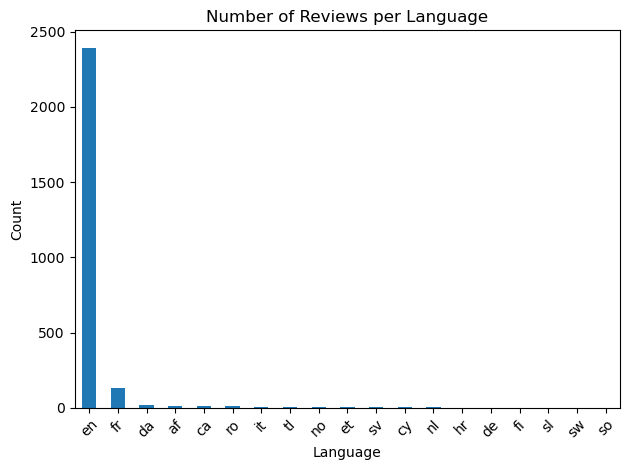

In [6]:
import matplotlib.pyplot as plt

# 1. Count the occurrences of each category and sort them
# Using sort_values(ascending=False) ensures the bars are in descending order
cat_counts = df['lang'].value_counts().sort_values(ascending=False)

# 2. Create the bar plot
cat_counts.plot(kind='bar')

# 3. Add labels and title
plt.title('Number of Reviews per Language')
plt.xlabel('Language')
plt.ylabel('Count')

# 4. Improve layout and show/save
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('bar_plot.png')
plt.show()

In [7]:
english_rate = len(df[df.lang == 'en'])/len(df)
english_rate

0.9181398923904689

In [8]:
french_rate = len(df[df.lang == 'fr'])/len(df)
french_rate

0.05073020753266718

In [9]:
df.to_csv("cleaned_data/cleaned_Study_1_reviews.csv", index=False)

# Study 4: Restaurant

In [10]:
df_4 = pd.read_excel("initial_data/Study 4 reviews.xlsx")

print(df_4.shape)

df_4.head()

(623, 14)


,ID,text,Satisfaction_RA2,Quality_and_taste_of_food,Cleanliness,Friendliness_of_staff,Value,Speed_of_service,Quality_and_taste_of_food_sentiment,Cleanliness_sentiment,Friendliness_of_staff_sentiment,Value_sentiment,Speed_of_service_sentiment,Emotional_intensity_LLM
0,1,Not so good,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,Decent,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,Could be better,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,Alright,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,OK,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
df_4.columns

Index(['ID', 'text', 'Satisfaction_RA2', 'Quality_and_taste_of_food',
       'Cleanliness', 'Friendliness_of_staff', 'Value', 'Speed_of_service',
       'Quality_and_taste_of_food_sentiment', 'Cleanliness_sentiment',
       'Friendliness_of_staff_sentiment', 'Value_sentiment',
       'Speed_of_service_sentiment', 'Emotional_intensity_LLM'],
      dtype='object')

In [12]:
df_4['text'].isna().sum()

0

In [13]:
from langdetect import detect, DetectorFactory, LangDetectException

# Ensure consistent language detection results
DetectorFactory.seed = 0

def safe_detect(text):
    # 1. Check if it's a valid string (handles NaN/floats)
    if not isinstance(text, str):
        return "unknown"
    
    # FIX: If text is very short, just assume English (or your main language)
    # Most 1-word reviews in this dataset seem to be English
    if len(text) < 15:
        return "en"
        
    # 3. Try/Except block as a final safety net
    try:
        return detect(text)
    except LangDetectException:
        return "unknown"

# Apply the SAFE function, not the raw detect function
df_4['lang'] = df_4['text'].apply(safe_detect)

# Check the results
print(df_4[['text', 'lang']].head(25))


                                  text lang
0                          Not so good   en
1                               Decent   en
2                      Could be better   en
3                              Alright   en
4                                   OK   en
5            The girl was not friendly   en
6      Room for improvement definitely   en
7        I wonder if she could hear me   en
8              Friendlier staff needed   da
9                     Kept me waiting!   id
10             Not sure how to rate it   en
11                              Lovely   en
12                                  OK   en
13            The person there is rude   en
14               I had to wait so long   en
15                                 Bad   en
16                           Warm food   en
17  I greeted friendly but no response   en
18                  Not helpful at all   en
19             Coffee is not expensive   en
20                          Ignored me   en
21                          Conv

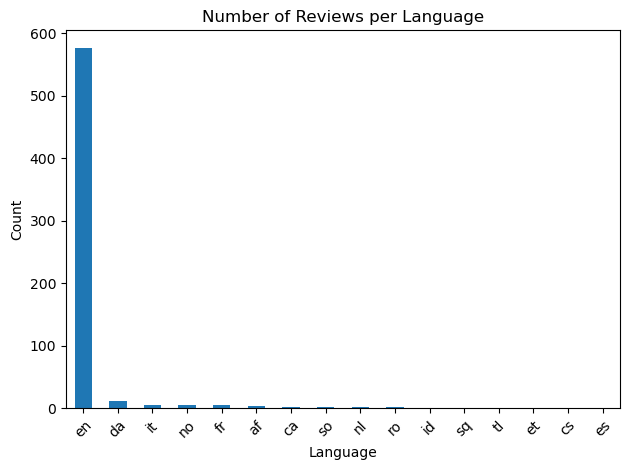

In [14]:
import matplotlib.pyplot as plt

# 1. Count the occurrences of each category and sort them
# Using sort_values(ascending=False) ensures the bars are in descending order
cat_counts = df_4['lang'].value_counts().sort_values(ascending=False)

# 2. Create the bar plot
cat_counts.plot(kind='bar')

# 3. Add labels and title
plt.title('Number of Reviews per Language')
plt.xlabel('Language')
plt.ylabel('Count')

# 4. Improve layout and show/save
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('bar_plot.png')
plt.show()

In [15]:
df_4.to_csv("cleaned_data/cleaned_Study_4_reviews.csv", index=False)

# Study 5: Restaurant

In [16]:
df_5 = pd.read_excel("initial_data/Study 5 reviews.xlsx")

print(df_5.shape)

df_5.head()

(717, 15)


,ID,Review,Satisfaction_final,Cleanliness_and_maintenance,Waiting_and_queuing_times,Quality_of_exhibits,Quantity_of_exhibits,Helfpulness_of_staff,Cleanliness_and_maintenance_sentiment,Waiting_and_queuing_times_sentiment,Quality_of_exhibits_sentiment,Quantity_of_exhibits_sentiment,Helfpulness_of_staff_sentiment,Unnamed: 13,Emotional_intensity_LLM
0,1,Very bad,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,horrible,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,Had a bad time here,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,Crowded paths,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,Horrible,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [17]:
df_5.columns

Index(['ID', 'Review', 'Satisfaction_final', 'Cleanliness_and_maintenance',
       'Waiting_and_queuing_times', 'Quality_of_exhibits',
       'Quantity_of_exhibits', 'Helfpulness_of_staff',
       'Cleanliness_and_maintenance_sentiment',
       'Waiting_and_queuing_times_sentiment', 'Quality_of_exhibits_sentiment',
       'Quantity_of_exhibits_sentiment', 'Helfpulness_of_staff_sentiment',
       'Unnamed: 13', 'Emotional_intensity_LLM'],
      dtype='object')

In [18]:
df_5['Review'].isna().sum()

0

In [19]:
from langdetect import detect, DetectorFactory, LangDetectException

# Ensure consistent language detection results
DetectorFactory.seed = 0

def safe_detect(text):
    # 1. Check if it's a valid string (handles NaN/floats)
    if not isinstance(text, str):
        return "unknown"
    
    # FIX: If text is very short, just assume English (or your main language)
    # Most 1-word reviews in this dataset seem to be English
    if len(text) < 15:
        return "en"
        
    # 3. Try/Except block as a final safety net
    try:
        return detect(text)
    except LangDetectException:
        return "unknown"

# Apply the SAFE function, not the raw detect function
df_5['lang'] = df_5['Review'].apply(safe_detect)

# Check the results
print(df_5[['Review', 'lang']].head(25))


                                   Review lang
0                                Very bad   en
1                                horrible   en
2                     Had a bad time here   en
3                           Crowded paths   en
4                                Horrible   en
5             Too tiring, exhausted by it   en
6               Felt tired and burned out   en
7                                dreadful   en
8                      Cafteria is a joke   en
9          Restrooms are too hard to find   en
10                      don't visit again   fr
11                          Loud visitors   en
12  Felt dark and claustrophobic in parts   en
13                     Just not very good   en
14       nightmare experience, too tiring   en
15                                    bad   en
16                            Few benches   en
17                      Poor descriptions   fr
18                           Dirty floors   en
19                           Few exhibits   en
20           

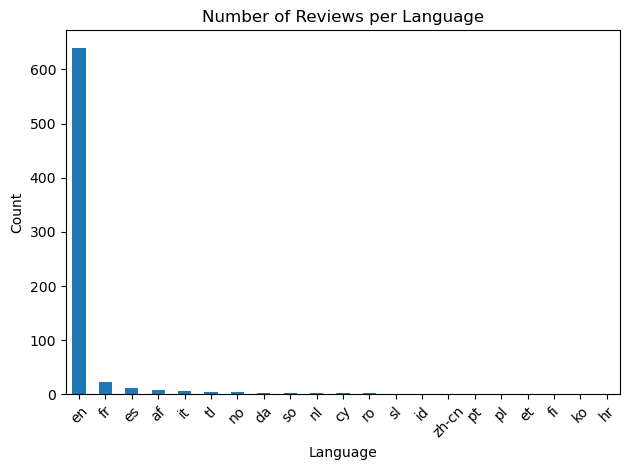

In [20]:
import matplotlib.pyplot as plt

# 1. Count the occurrences of each category and sort them
# Using sort_values(ascending=False) ensures the bars are in descending order
cat_counts = df_5['lang'].value_counts().sort_values(ascending=False)

# 2. Create the bar plot
cat_counts.plot(kind='bar')

# 3. Add labels and title
plt.title('Number of Reviews per Language')
plt.xlabel('Language')
plt.ylabel('Count')

# 4. Improve layout and show/save
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('bar_plot.png')
plt.show()

In [21]:
df_5.to_csv("cleaned_data/cleaned_Study_5_reviews.csv", index=False)